# E-field density: vacuum / C8H8 / Si (s and p)

Toy stack at 250 eV with **lab-frame** coordinates (beam from the top):

| Region                                      | $z$ (nm)          |
| ------------------------------------------- | ----------------- |
| **Vacuum** (incident semi-infinite)         | $z > 200$         |
| **C8H8** film ($\rho = 1\,\mathrm{g/cm^3}$) | $0 \le z \le 200$ |
| **Si** substrate                            | $z < 0$           |

Reflectivity uses `tjf4x4` (vacuum fronting); field maps use $z_\mathrm{tmm} = d - z$.

**Wavefronts and grazing incidence:** at $q_c$ here $\theta \approx 3.7^\circ$ from the surface normal ($k_x \gg k_z$, so $|k_x/k_z| \approx 16$). The top row plots the **pure vacuum incident phase** $\Re(e^{i(k_x x + k_z z_\mathrm{tmm})})$ — tilted fringes show the beam is **not** normally incident. s-pol $|E_y|^2$ is flat in $x$ (intensity cannot show propagation direction). s-pol $\Re(E_y e^{ik_x x})$ oscillates in $x$ only (vertical stripes). p-pol rows show oblique standing-wave structure in the incidence plane.

Two conditions: **$q_c$** (TER edge) and **first Kiessig minimum** above $q_c$.


In [11]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from periodictable.xsf import index_of_refraction
from scipy.signal import argrelmin

from refloxide.pxr.tjf4x4 import calculate_kz_uni, hc, uniaxial_reflectivity
from refloxide.pxr.stacks import Layer, Material, stack_slabs, stack_tensor

ENERGY_EV = 250.0
FILM_NM = 200.0
FILM_A = FILM_NM * 10.0


def c8h8_n(energy_ev: float) -> complex:
    return index_of_refraction("C8H8", density=1.0, energy=energy_ev * 1e-3)


def si_n(energy_ev: float) -> complex:
    return index_of_refraction("Si", density=2.33, energy=energy_ev * 1e-3)


def build_layers(energy_ev: float = ENERGY_EV) -> list[Layer]:
    """Return the smooth vacuum / C8H8 / Si stack used for field maps."""
    return [
        Layer(
            thickness=0.0,
            roughness=0.0,
            material=Material("scalar"),
            sld=complex(1.0, 0.0),
        ),
        Layer(
            thickness=FILM_A,
            roughness=0.0,
            material=Material("uniaxial"),
            sld=c8h8_n,
        ),
        Layer(
            thickness=0.0,
            roughness=0.0,
            material=Material("scalar"),
            sld=si_n,
        ),
    ]


layers = build_layers()
slabs = np.asarray(stack_slabs(layers, energy=ENERGY_EV), dtype=np.float64)
tensor = np.asarray(stack_tensor(layers, energy=ENERGY_EV), dtype=np.complex128)

n_vac = complex(1.0, 0.0)
n_film = c8h8_n(ENERGY_EV)
n_si = si_n(ENERGY_EV)
wavelength_a = hc / ENERGY_EV
k0 = 2.0 * np.pi / wavelength_a

print(f"energy = {ENERGY_EV} eV, lambda = {wavelength_a:.3f} A")
print(f"n_film = {n_film:.6f}, n_Si = {n_si:.6f}")
print(f"film thickness = {FILM_NM:.1f} nm ({FILM_A:.0f} A)")

energy = 250.0 eV, lambda = 49.594 A
n_film = 0.997947-0.000103j, n_Si = 0.994028-0.004250j
film thickness = 200.0 nm (2000 A)


In [12]:
def kx_from_q(q: float, k0: float = k0) -> complex:
    """In-plane wavenumber matching ``refloxide.pxr.tjf4x4`` grazing convention."""
    return k0 * np.sqrt(1.0 - (q / (2.0 * k0)) ** 2 + 0j)


def kz_forward_uniaxial(n: complex, kx: complex, k0_val: float = k0) -> complex:
    """Forward ordinary ``k_z`` from the same branch as ``tjf4x4.calculate_kz_uni``."""
    delta_beta = 1.0 - n
    tensor_row = np.conj(np.eye(3) - 2.0 * np.diag([delta_beta, delta_beta, delta_beta]))
    kz_all = calculate_kz_uni(
        tensor_row,
        np.asarray([kx], dtype=np.complex128),
        np.asarray([0.0], dtype=np.float64),
        k0_val,
    )
    return complex(kz_all[0, 2])


def complex_s_amplitudes(
    q: float,
    *,
    slabs_arr: np.ndarray = slabs,
    tensor_arr: np.ndarray = tensor,
    energy_ev: float = ENERGY_EV,
) -> tuple[complex, complex]:
    """Jones s-reflection and transmission amplitudes at one ``q`` from the 4x4 matrix."""
    _refl, _tran, *_rest, m_full = uniaxial_reflectivity(
        np.asarray([q], dtype=np.float64),
        slabs_arr,
        tensor_arr,
        energy_ev,
    )
    m0 = m_full[0]
    denom = m0[0, 0] * m0[2, 2] - m0[0, 2] * m0[2, 0]
    r_ss = (m0[1, 0] * m0[2, 2] - m0[1, 2] * m0[2, 0]) / denom
    t_ss = m0[2, 2] / denom
    return complex(r_ss), complex(t_ss)


def film_forward_backward(
    r: complex, kz0: complex, kz1: complex
) -> tuple[complex, complex]:
    """Forward/backward s-field amplitudes at the vacuum/film interface (z = 0)."""
    forward = 0.5 * ((1.0 + r) + (kz0 / kz1) * (1.0 - r))
    backward = 0.5 * ((1.0 + r) - (kz0 / kz1) * (1.0 - r))
    return forward, backward


def lab_z_to_tmm(z_lab_a: float | np.ndarray, thickness_a: float = FILM_A) -> float | np.ndarray:
    """Map lab depth (Si at $z<0$, vacuum at $z>d$) to the tjf4x4 frame ($z_\\mathrm{tmm}=d-z$)."""
    return thickness_a - z_lab_a


def s_field_amplitude(
    q: float,
    z_tmm_a: float,
    *,
    n0: complex = n_vac,
    n1: complex = n_film,
    thickness_a: float = FILM_A,
    n2: complex = n_si,
) -> complex:
    """Complex s-polarized $E_y$ at one depth in the tjf4x4 coordinate (vacuum $z<0$, Si $z>d$)."""
    r, t = complex_s_amplitudes(q)
    kx = kx_from_q(q)
    kz0 = kz_forward_uniaxial(n0, kx)
    kz1 = kz_forward_uniaxial(n1, kx)
    kz2 = kz_forward_uniaxial(n2, kx)
    forward, backward = film_forward_backward(r, kz0, kz1)

    z = z_tmm_a
    if z < 0.0:
        return np.exp(1j * kz0 * z) + r * np.exp(-1j * kz0 * z)
    if z <= thickness_a:
        return forward * np.exp(1j * kz1 * z) + backward * np.exp(-1j * kz1 * z)
    return t * np.exp(1j * kz2 * (z - thickness_a))


def s_field_maps(
    q: float,
    x_a: np.ndarray,
    z_lab_a: np.ndarray,
    *,
    thickness_a: float = FILM_A,
) -> tuple[np.ndarray, np.ndarray]:
    """Return $|E_y|^2$ and $\\Re(E_y e^{ik_x x})$ on lab-frame $(x, z)$ grids."""
    kx = kx_from_q(q)
    x_phase = np.exp(1j * kx * x_a)
    density = np.zeros((z_lab_a.size, x_a.size), dtype=np.float64)
    real_part = np.zeros((z_lab_a.size, x_a.size), dtype=np.float64)

    for iz, z_lab in enumerate(z_lab_a):
        ey = s_field_amplitude(q, lab_z_to_tmm(z_lab, thickness_a))
        wave = ey * x_phase
        density[iz, :] = np.abs(wave) ** 2
        real_part[iz, :] = np.real(wave)

    return density, real_part


def theta_from_normal_deg(q: float, k0_val: float = k0) -> float:
    """Incidence angle from the surface normal (degrees) for the ``tjf4x4`` $q$ convention."""
    return float(np.degrees(np.arcsin(np.clip(q / (2.0 * k0_val), -1.0, 1.0))))


def complex_p_amplitudes(
    q: float,
    *,
    slabs_arr: np.ndarray = slabs,
    tensor_arr: np.ndarray = tensor,
    energy_ev: float = ENERGY_EV,
) -> tuple[complex, complex]:
    """Jones p-reflection and transmission amplitudes at one ``q`` from the 4x4 matrix."""
    _refl, _tran, *_rest, m_full = uniaxial_reflectivity(
        np.asarray([q], dtype=np.float64),
        slabs_arr,
        tensor_arr,
        energy_ev,
    )
    m0 = m_full[0]
    denom = m0[0, 0] * m0[2, 2] - m0[0, 2] * m0[2, 0]
    r_pp = (m0[0, 0] * m0[3, 2] - m0[3, 0] * m0[0, 2]) / denom
    t_pp = m0[0, 0] / denom
    return complex(r_pp), complex(t_pp)


def p_e_components_from_hy(
    hy: complex,
    kx: complex,
    kz: complex,
    n: complex,
    *,
    k0_val: float = k0,
) -> tuple[complex, complex]:
    """Map $H_y$ to in-plane $E_x$, $E_z$ in an isotropic layer ($\\mathbf{k}\\cdot\\mathbf{E}=0$)."""
    scale = kz / (n * k0_val**2)
    ex = hy * scale
    ez = -hy * kx / (n * k0_val**2)
    return ex, ez


def p_field_amplitude(
    q: float,
    z_tmm_a: float,
    *,
    n0: complex = n_vac,
    n1: complex = n_film,
    thickness_a: float = FILM_A,
    n2: complex = n_si,
) -> tuple[complex, complex]:
    """In-plane p-polarized $(E_x, E_z)$ at one depth in the tjf4x4 frame."""
    r, t = complex_p_amplitudes(q)
    kx = kx_from_q(q)
    kz0 = kz_forward_uniaxial(n0, kx)
    kz1 = kz_forward_uniaxial(n1, kx)
    kz2 = kz_forward_uniaxial(n2, kx)
    forward, backward = film_forward_backward(r, kz0, kz1)
    incident_hy = k0

    z = z_tmm_a
    if z < 0.0:
        hy = incident_hy * (np.exp(1j * kz0 * z) + r * np.exp(-1j * kz0 * z))
        return p_e_components_from_hy(hy, kx, kz0, n0)
    if z <= thickness_a:
        hy = incident_hy * (
            forward * np.exp(1j * kz1 * z) + backward * np.exp(-1j * kz1 * z)
        )
        return p_e_components_from_hy(hy, kx, kz1, n1)
    hy = incident_hy * t * np.exp(1j * kz2 * (z - thickness_a))
    return p_e_components_from_hy(hy, kx, kz2, n2)


def p_field_maps(
    q: float,
    x_a: np.ndarray,
    z_lab_a: np.ndarray,
    *,
    thickness_a: float = FILM_A,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return $|E_x|^2+|E_z|^2$, $\\Re(E_x e^{ik_x x})$, and $\\Re(E_x e^{i(k_x x + k_z z_\\mathrm{tmm})})$."""
    kx = kx_from_q(q)
    x_phase = np.exp(1j * kx * x_a)
    density = np.zeros((z_lab_a.size, x_a.size), dtype=np.float64)
    real_ex = np.zeros((z_lab_a.size, x_a.size), dtype=np.float64)
    real_traveling = np.zeros((z_lab_a.size, x_a.size), dtype=np.float64)

    for iz, z_lab in enumerate(z_lab_a):
        z_tmm = lab_z_to_tmm(z_lab, thickness_a)
        ex, ez = p_field_amplitude(q, z_tmm)
        kz_layer = kz_forward_uniaxial(
            n_vac if z_tmm < 0 else (n_film if z_tmm <= thickness_a else n_si),
            kx,
        )
        wave_x = ex * x_phase
        wave_z = ez * x_phase
        density[iz, :] = np.abs(wave_x) ** 2 + np.abs(wave_z) ** 2
        real_ex[iz, :] = np.real(wave_x)
        phase = kx * x_a + kz_layer * z_tmm
        real_traveling[iz, :] = np.real(ex * np.exp(1j * phase))

    return density, real_ex, real_traveling


def incident_phase_map_lab(
    q: float,
    x_a: np.ndarray,
    z_lab_a: np.ndarray,
    *,
    thickness_a: float = FILM_A,
) -> np.ndarray:
    """Pure vacuum incident phase $\\Re(e^{i(k_x x + k_z z_\\mathrm{tmm})})$; NaN outside vacuum ($z > d$)."""
    kx = kx_from_q(q)
    kz0 = kz_forward_uniaxial(n_vac, kx)
    x_grid, z_grid = np.meshgrid(x_a, z_lab_a, indexing="xy")
    z_tmm = thickness_a - z_grid
    phase = np.real(np.exp(1j * (kx * x_grid + kz0 * z_tmm)))
    return np.where(z_grid > thickness_a, phase, np.nan)


def critical_q(n_film_val: complex, k0_val: float = k0) -> float:
    """Vacuum/film critical q where Re(kz_film) crosses zero (total external reflection edge)."""
    delta = 1.0 - np.real(n_film_val)
    return 2.0 * k0_val * np.sqrt(2.0 * delta)


def first_fringe_extinction_q(
    q_grid: np.ndarray,
    reflectivity: np.ndarray,
    q_c: float,
    *,
    order: int = 20,
) -> tuple[float, float]:
    """First local reflectivity minimum above ``q_c`` (destructive film interference)."""
    mask = q_grid > q_c * 1.001
    q_above = q_grid[mask]
    r_above = reflectivity[mask]
    minima = argrelmin(r_above, order=order)[0]
    if minima.size == 0:
        raise RuntimeError("No reflectivity minimum found above q_c.")
    idx = int(minima[0])
    return float(q_above[idx]), float(r_above[idx])

q_c = 0.016237 A^-1, theta = 3.674 deg from normal
R_ss(q_c) = 0.5344, R_pp(q_c) = 0.5358
first fringe extinction: q = 0.017361 A^-1, R_ss = 1.653e-01
  theta at extinction = 3.929 deg


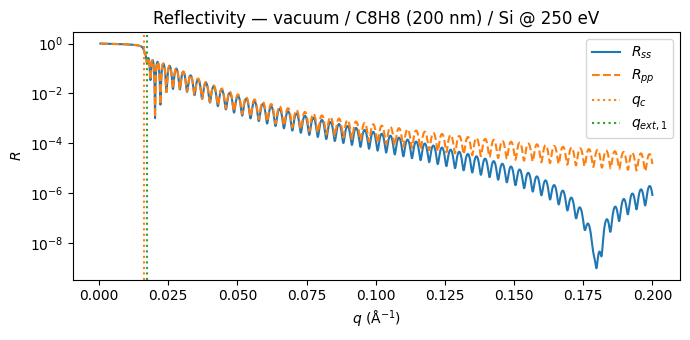

In [13]:
q_scan = np.linspace(0.0005, 0.2, 6000)
refl_tjf, *_ = uniaxial_reflectivity(q_scan, slabs, tensor, ENERGY_EV)
R_ss_tjf = refl_tjf[:, 0, 0]
R_pp_tjf = refl_tjf[:, 1, 1]

q_c = critical_q(n_film)
q_ext, r_ext = first_fringe_extinction_q(q_scan, R_ss_tjf, q_c)

idx_c = int(np.argmin(np.abs(q_scan - q_c)))
print(f"q_c = {q_c:.6f} A^-1, theta = {theta_from_normal_deg(q_c):.3f} deg from normal")
print(f"R_ss(q_c) = {R_ss_tjf[idx_c]:.4f}, R_pp(q_c) = {R_pp_tjf[idx_c]:.4f}")
print(f"first fringe extinction: q = {q_ext:.6f} A^-1, R_ss = {r_ext:.3e}")
print(f"  theta at extinction = {theta_from_normal_deg(q_ext):.3f} deg")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.semilogy(q_scan, R_ss_tjf, label=r"$R_{ss}$")
ax.semilogy(q_scan, R_pp_tjf, label=r"$R_{pp}$", ls="--")
ax.axvline(q_c, color="C1", ls=":", label=rf"$q_c$")
ax.axvline(q_ext, color="C2", ls=":", label=rf"$q_{{ext,1}}$")
ax.set_xlabel(r"$q$ (Å$^{-1}$)")
ax.set_ylabel(r"$R$")
ax.set_title("Reflectivity — vacuum / C8H8 (200 nm) / Si @ 250 eV")
ax.legend(loc="upper right")
fig.tight_layout()

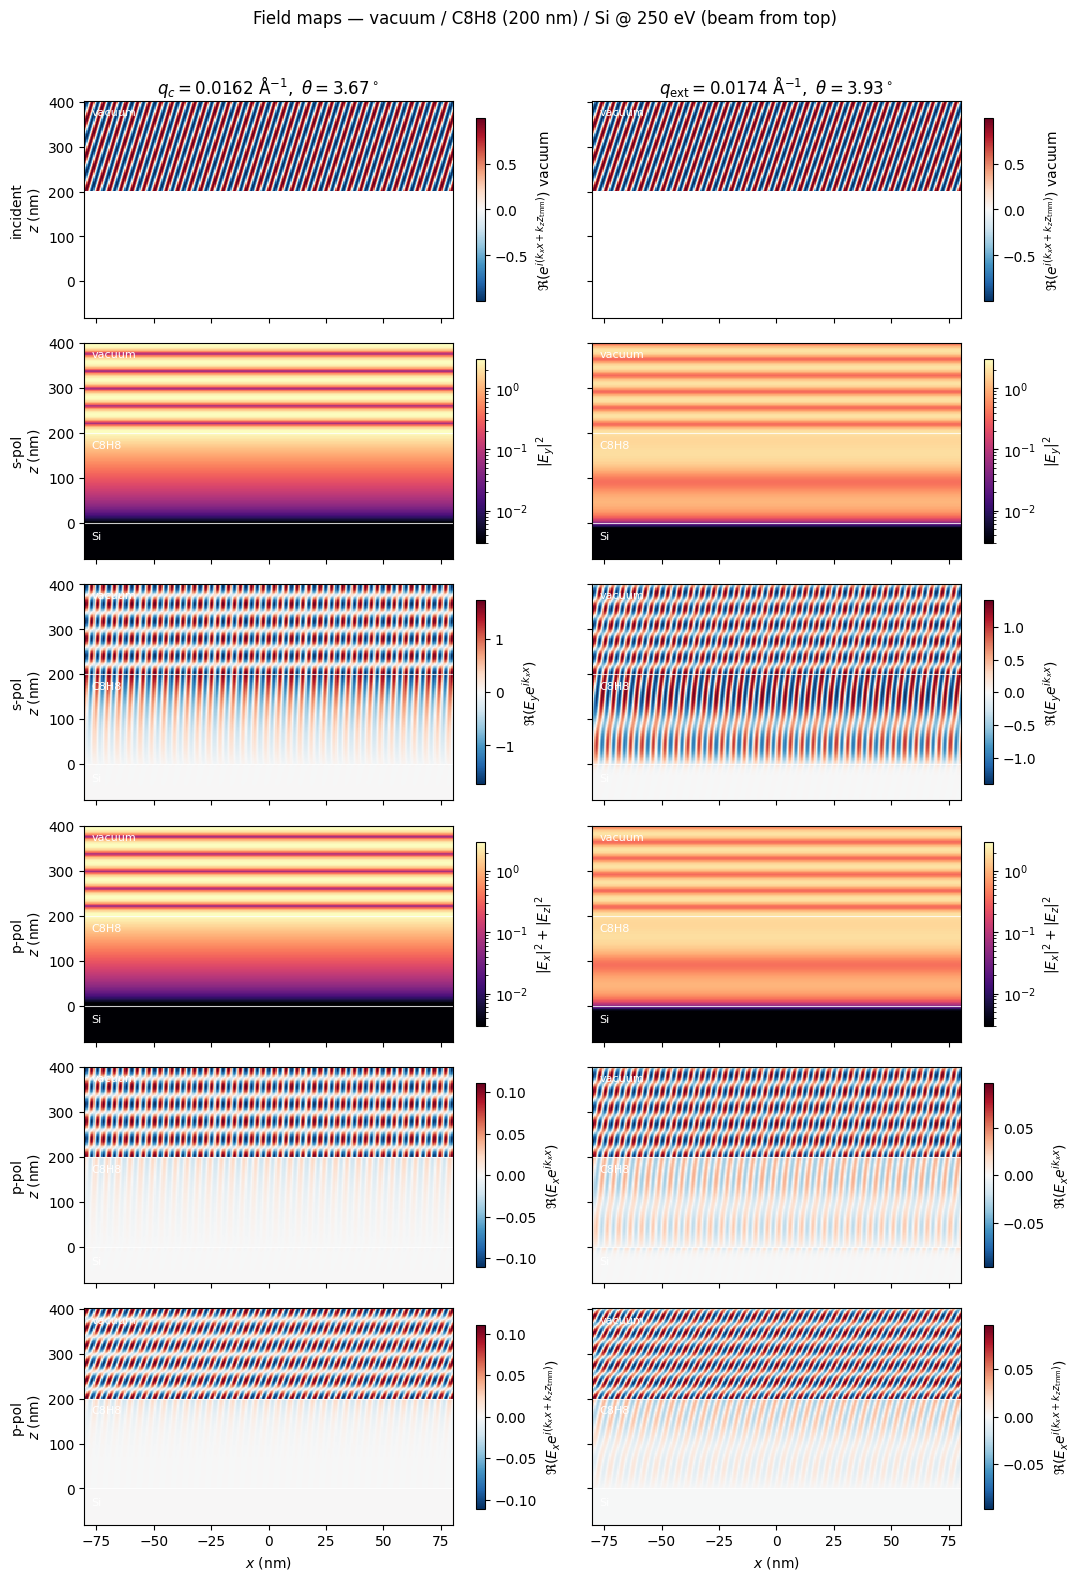

In [14]:
x_nm = np.linspace(-80.0, 80.0, 320)
z_nm = np.linspace(-80.0, 400.0, 360)
x_a = x_nm * 10.0
z_lab_a = z_nm * 10.0

conditions = {
    rf"$q_c = {q_c:.4f}\ \mathrm{{\AA}}^{{-1}},\ \theta={theta_from_normal_deg(q_c):.2f}^\circ$": q_c,
    rf"$q_{{\mathrm{{ext}}}} = {q_ext:.4f}\ \mathrm{{\AA}}^{{-1}},\ \theta={theta_from_normal_deg(q_ext):.2f}^\circ$": q_ext,
}

s_maps = {label: s_field_maps(q_val, x_a, z_lab_a) for label, q_val in conditions.items()}
p_maps = {label: p_field_maps(q_val, x_a, z_lab_a) for label, q_val in conditions.items()}
ref_maps = {
    label: incident_phase_map_lab(q_val, x_a, z_lab_a) for label, q_val in conditions.items()
}

vmax_s = max(u.max() for u, _ in s_maps.values())
vmax_p = max(u.max() for u, _, _ in p_maps.values())

rows = [
    ("ref", r"$\Re(e^{i(k_x x + k_z z_\mathrm{tmm})})$ vacuum", "RdBu_r", lambda _m, label: (ref_maps[label], None)),
    ("s", r"$|E_y|^2$", "magma", lambda m, label: (m[label][0], LogNorm(vmin=max(vmax_s * 1e-3, 1e-4), vmax=vmax_s))),
    ("s", r"$\Re(E_y e^{ik_x x})$", "RdBu_r", lambda m, label: (m[label][1], None)),
    ("p", r"$|E_x|^2+|E_z|^2$", "magma", lambda m, label: (m[label][0], LogNorm(vmin=max(vmax_p * 1e-3, 1e-4), vmax=vmax_p))),
    ("p", r"$\Re(E_x e^{ik_x x})$", "RdBu_r", lambda m, label: (m[label][1], None)),
    ("p", r"$\Re(E_x e^{i(k_x x + k_z z_\mathrm{tmm})})$", "RdBu_r", lambda m, label: (m[label][2], None)),
]

fig, axes = plt.subplots(len(rows), 2, figsize=(11, 2.6 * len(rows)), sharex=True, sharey=True)
labels = list(conditions.keys())

for row_idx, (pol, ylabel, cmap, getter) in enumerate(rows):
    maps = s_maps if pol == "s" else (p_maps if pol == "p" else None)
    for col_idx, label in enumerate(labels):
        ax = axes[row_idx, col_idx]
        data, norm = getter(maps, label)
        im = ax.pcolormesh(x_nm, z_nm, data, shading="auto", cmap=cmap, norm=norm)
        ax.axhline(0.0, color="w", lw=0.8, alpha=0.8)
        ax.axhline(FILM_NM, color="w", lw=0.8, alpha=0.8)
        ax.text(0.02, 0.97, "vacuum", transform=ax.transAxes, va="top", color="w", fontsize=8)
        ax.text(0.02, 0.55, "C8H8", transform=ax.transAxes, va="top", color="w", fontsize=8)
        ax.text(0.02, 0.08, "Si", transform=ax.transAxes, va="bottom", color="w", fontsize=8)
        if row_idx == 0:
            ax.set_title(label)
        if col_idx == 0:
            row_label = "incident" if pol == "ref" else f"{pol}-pol"
            ax.set_ylabel(f"{row_label}\n$z$ (nm)")
        fig.colorbar(im, ax=ax, label=ylabel, shrink=0.85)

for ax in axes[-1, :]:
    ax.set_xlabel(r"$x$ (nm)")

fig.suptitle("Field maps — vacuum / C8H8 (200 nm) / Si @ 250 eV (beam from top)", y=1.01)
fig.tight_layout()
plt.show()